# Enrichment review: cost and trust analysis

This notebook uses **SQL (SQLite)** and **pandas** to answer the questions behind the review console.

The data is one AI enrichment run (830 SKUs, 11,087 proposed values), grouped into 15 error classes. It's exported from the app's TypeScript catalog with `npm run export:data`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pipeline

con = pipeline.connect()
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
[q.key for q in pipeline.load_queries()]

['01_lane_mix',
 '02_review_cost',
 '03_trust_matrix',
 '04_policy_violations',
 '05_pareto',
 '06_failure_modes',
 '07_held_by_owner']

## 1. How much can be cleared by policy?

In [2]:
pipeline.run(con, "01")

,lane,classes,values,pct_of_values
0,auto,8,7332,66.1
1,review,4,3089,27.9
2,hold,3,666,6.0


## 2. What does review cost, row by row vs. by class?

,total_values,row_by_row_hours,audit_rows,class_based_hours,values_per_decision
0,11087,27.7,147,1.4,695.0


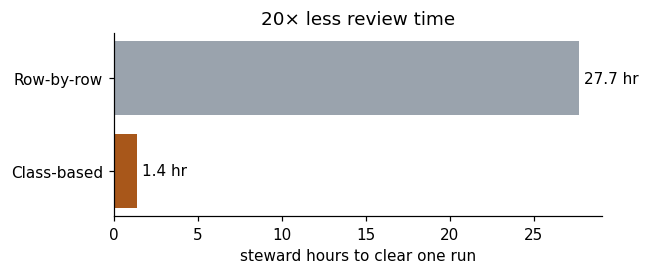

In [3]:
cost = pipeline.run(con, "02")
c = cost.iloc[0]
fig, ax = plt.subplots(figsize=(6, 2.6))
ax.barh(["Class-based", "Row-by-row"], [c.class_based_hours, c.row_by_row_hours], color=["#A8571A", "#9aa3ad"])
for y, v in enumerate([c.class_based_hours, c.row_by_row_hours]):
    ax.text(v + 0.3, y, f"{v} hr", va="center")
ax.set_xlabel("steward hours to clear one run")
ax.set_title(f"{c.row_by_row_hours / c.class_based_hours:.0f}× less review time")
plt.tight_layout(); fig.savefig("figures/review_cost.png")
cost

## 3. Trust matrix: source tier × lane
Only tier-1, corroborated sources ever reach the auto lane.

,auto,review,hold,total
source_tier,,,,
1,7332,1182,0,8514
2,0,1907,146,2053
3,0,0,520,520


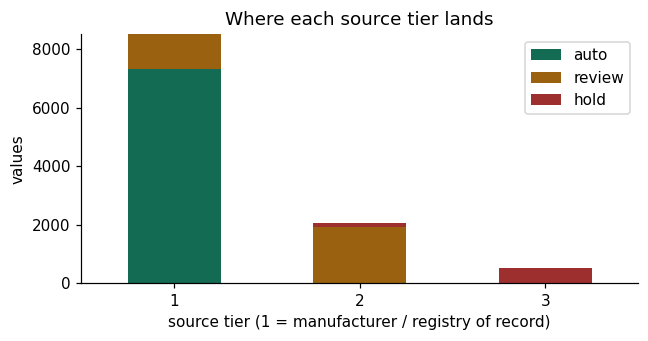

In [4]:
m = pipeline.run(con, "03").set_index("source_tier")
ax = m[["auto", "review", "hold"]].plot.bar(stacked=True, figsize=(6, 3.2), color=["#146B54", "#9A6210", "#9E2F2F"], rot=0)
ax.set_xlabel("source tier (1 = manufacturer / registry of record)"); ax.set_ylabel("values")
ax.set_title("Where each source tier lands")
plt.tight_layout(); plt.savefig("figures/trust_matrix.png")
m

## 4. Policy check
This query should return no rows. A test fails the build if it ever does.

In [5]:
pipeline.run(con, "04")

,class_id,title,source_tier,corroborating_sources,worst_sample_tier


## 5. Pareto: how few decisions clear most of the run?

,class_id,lane,values_count,cumulative_values,cumulative_pct,decisions
0,volt,auto,1842,1842,17.7,1
1,desc,review,1530,3372,32.4,2
2,mfr,auto,1204,4576,43.9,3
3,amp,auto,1105,5681,54.5,4
4,nema,auto,946,6627,63.6,5
5,schema,review,918,7545,72.4,6
6,awg,auto,733,8278,79.4,7
7,weight,auto,612,8890,85.3,8
8,upc,auto,488,9378,90.0,9
9,conduit,auto,402,9780,93.8,10


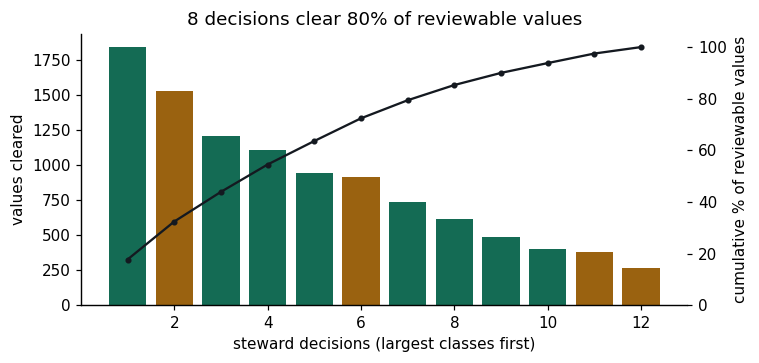

In [6]:
p = pipeline.run(con, "05")
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(p.decisions, p.values_count, color=["#146B54" if l == "auto" else "#9A6210" for l in p.lane])
ax2 = ax.twinx(); ax2.plot(p.decisions, p.cumulative_pct, color="#141920", marker="o", ms=3)
ax2.set_ylim(0, 105); ax2.set_ylabel("cumulative % of reviewable values")
ax.set_xlabel("steward decisions (largest classes first)"); ax.set_ylabel("values cleared")
ax.set_title("8 decisions clear 80% of reviewable values")
plt.tight_layout(); fig.savefig("figures/pareto.png")
p

## 6. Failure modes by volume

In [7]:
pipeline.run(con, "06")

,failure_mode,classes,values,lanes,fields
0,unit-format,3,2977,auto,Voltage; Conductor Size; Trade Size
1,channel-format,1,1530,review,Long Description
2,entity-alias,1,1204,auto,Manufacturer
3,pdf-table-extract,1,1105,auto,Ampacity
4,enum-drift,1,946,auto,Enclosure Rating
5,schema-collision,1,918,review,Diameter / Width / OD
6,unit-convert,1,612,auto,Shipping Weight
7,checksum,1,488,auto,UPC
8,no-citation,1,377,review,Enclosure Material
9,untrusted-source,1,311,hold,Country of Origin


## 7. What's held back, and the standing rule for each

In [8]:
pipeline.run(con, "07")

,field,values_count,source,standing_rule
0,Country of Origin,311,Third-party marketplace listing,NEVER auto-accept Country of Origin below sour...
1,UNSPSC Code,209,No citation,NEVER write UNSPSC without a source document —...
2,Safety Listing,146,Manufacturer marketing page,NEVER publish a safety listing absent from the...


## Takeaways

1. **Two thirds of the run is deterministic.** Unit formats, aliases, enums and checksums can be cleared by policy with a 2% audit sample.
2. **The cost falls about 20×**, from 27.7 to 1.4 steward hours per run, because the steward makes 15 decisions instead of 11,087.
3. **Trust comes from the rules, not from model confidence.** Tier-2 and tier-3 sources never auto-clear, and customs, tariff and safety fields are always held for a named owner.